<a href="https://colab.research.google.com/github/Pravallika-B6/AI_Powered_Intelligent_Traffic_Safety_and_Emergency_Response_System/blob/main/CRF_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, subprocess
import tensorflow as tf

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("TensorFlow  :", tf.__version__)
try:
    import keras
    print("Keras       :", keras.__version__)
except Exception as e:
    print("Keras import problem:", e)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)
for g in gpus:
    try:
        details = tf.config.experimental.get_device_details(g)
        print("  GPU name   :", details.get("device_name", "unknown"))
    except Exception:
        print("  GPU        :", g)
if gpus:
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv"],
                         capture_output=True, text=True).stdout)
else:
    print("No GPU found -> Runtime > Change runtime type > Hardware accelerator > T4 GPU")

Python      : 3.13.15
Platform    : Linux-6.6.122+-x86_64-with-glibc2.39
TensorFlow  : 2.21.0
Keras       : 3.13.2
GPU available: True
  GPU name   : Tesla T4
name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07



In [ ]:
import os, random, time, json, shutil, math, hashlib, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab - skipping Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ----------------------------- paths -----------------------------
DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/data3"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/CRFNet_results"   # change if you want another place
CKPT_DIR     = "/content/crfnet_checkpoints"                              # local, fast, temporary

# ----------------------------- experiment settings -----------------------------
QUICK_TEST   = False       # True -> 2 epochs per model, only to test that the pipeline runs
SEED         = 42
IMG_SIZE     = 224
BATCH_SIZE   = 16
MAX_EPOCHS   = 2 if QUICK_TEST else 60
INIT_LR      = 1e-4
WEIGHT_DECAY = 1e-2        # AdamW decoupled weight decay
ES_PATIENCE  = 8           # EarlyStopping patience (val_loss)
LR_PATIENCE  = 3           # ReduceLROnPlateau patience (val_loss)
USE_CLASS_WEIGHT = True    # the weights are printed in Section 4 so you can see their effect
ABLATION_SEEDS = [SEED]    # e.g. [42, 7, 123] to average several runs (3x longer, more trustworthy)

# ----------------------------- label mapping (EXPLICIT, never alphabetical) -----------------------------
CLASS_TO_LABEL = {"Non Accident": 0, "Accident": 1}
LABEL_TO_NAME  = {0: "Non Accident", 1: "Accident"}

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "misclassified_images"), exist_ok=True)

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    keras.utils.set_random_seed(seed)

set_seed(SEED)
print("Random seed :", SEED)
print("Results dir :", RESULTS_DIR)
print("Max epochs  :", MAX_EPOCHS)

[('.jpg', 990)]
['val', 'train', 'test']


In [ ]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

def list_split(split):
    paths, labels = [], []
    for cname, lab in CLASS_TO_LABEL.items():
        d = Path(DATASET_ROOT) / split / cname
        assert d.is_dir(), f"Folder not found: {d}\nCheck DATASET_ROOT and the folder names (Accident / Non_Accident)."
        files = sorted(p for p in d.iterdir() if p.suffix.lower() in IMG_EXT)
        paths += [str(p) for p in files]
        labels += [lab] * len(files)
    return np.array(paths), np.array(labels, dtype=np.int32)

train_paths, train_labels = list_split("train")
val_paths,   val_labels   = list_split("val")
test_paths,  test_labels  = list_split("test")
splits = {"train": (train_paths, train_labels), "val": (val_paths, val_labels), "test": (test_paths, test_labels)}

EXPECTED = {"train": (422, 370), "val": (52, 46), "test": (53, 47)}   # (Non_Accident, Accident)

print("=== Class-to-label mapping check ===")
rows = []
for split, (p, y) in splits.items():
    # verify every label really agrees with the folder the file came from
    for path, lab in zip(p, y):
        assert CLASS_TO_LABEL[Path(path).parent.name] == lab, f"Label mismatch for {path}"
    for cname, lab in CLASS_TO_LABEL.items():
        n = int((y == lab).sum())
        exp = EXPECTED[split][lab]
        rows.append({"split": split, "folder": cname, "label_index": lab, "count": n,
                     "expected": exp, "matches_expected": n == exp})
display(pd.DataFrame(rows))
print("Label mapping verified: Non_Accident = 0, Accident = 1 (all file paths checked)\n")

# ---- class distribution and class weights (computed from the TRAIN set only) ----
n_train = len(train_labels)
class_counts = {lab: int((train_labels == lab).sum()) for lab in (0, 1)}
class_weight = {lab: n_train / (2.0 * class_counts[lab]) for lab in (0, 1)}
print("=== Class weights (train set) : weight = N_total / (2 * N_class) ===")
display(pd.DataFrame([{"class name": LABEL_TO_NAME[l], "class index": l,
                       "number of samples": class_counts[l], "class weight": round(class_weight[l], 4)}
                      for l in (0, 1)]))
if not USE_CLASS_WEIGHT:
    class_weight = None
print("Class weights used in training:", class_weight)

# ---- leakage check: identical files appearing in more than one split ----
def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
seen = {}
for split, (p, _) in splits.items():
    for path in p:
        seen.setdefault(md5(path), set()).add(split)
n_leaks = sum(1 for s in seen.values() if len(s) > 1)
print(f"\nExact duplicate images shared between different splits: {n_leaks}")
if n_leaks:
    print("WARNING: remove these duplicates, otherwise test results are over-optimistic.")
print("NOTE: if your frames were cut from videos, near-identical neighbouring frames in different splits "
      "can still leak information. Ideally split by video/scene.")

=== Class-to-label mapping check ===


,split,folder,label_index,count,expected,matches_expected
0,train,Non Accident,0,422,422,True
1,train,Accident,1,370,370,True
2,val,Non Accident,0,52,52,True
3,val,Accident,1,46,46,True
4,test,Non Accident,0,53,53,True
5,test,Accident,1,47,47,True


Label mapping verified: Non_Accident = 0, Accident = 1 (all file paths checked)

=== Class weights (train set) : weight = N_total / (2 * N_class) ===


,class name,class index,number of samples,class weight
0,Non Accident,0,422,0.9384
1,Accident,1,370,1.0703


Class weights used in training: {0: 0.9383886255924171, 1: 1.0702702702702702}

Exact duplicate images shared between different splits: 11
NOTE: if your frames were cut from videos, near-identical neighbouring frames in different splits can still leak information. Ideally split by video/scene.


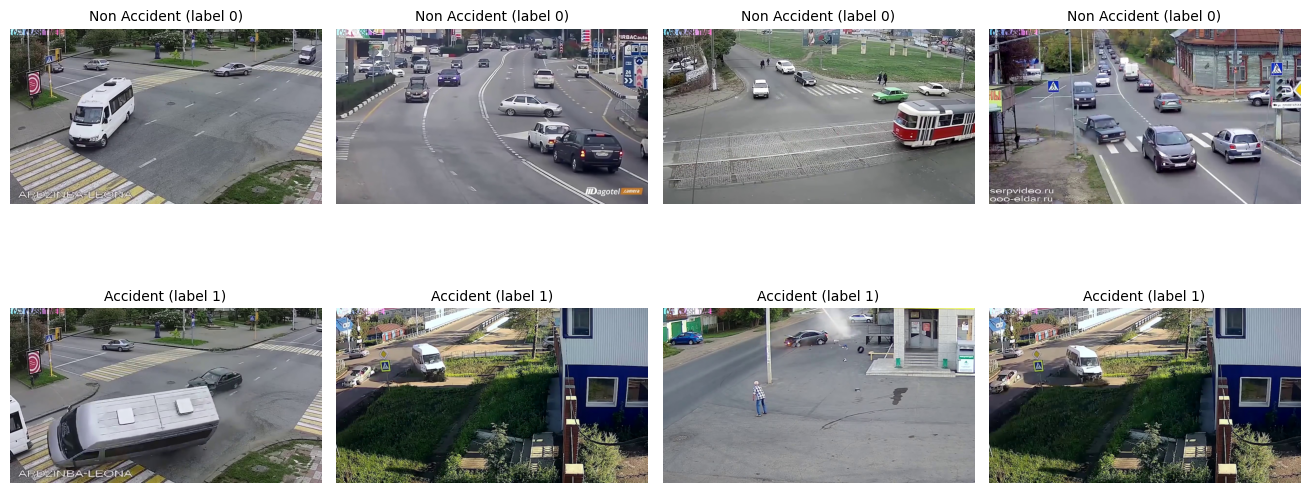

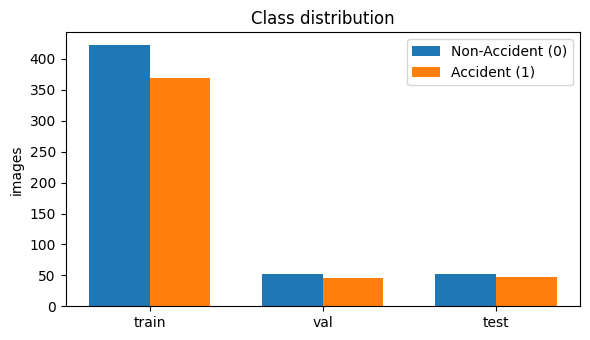

Example original image sizes (width, height): [(720, 576), (1280, 720)]


In [ ]:
def show_samples(paths, labels, n=4, seed=SEED):
    rng = np.random.RandomState(seed)
    fig, axes = plt.subplots(2, n, figsize=(3.3 * n, 6.6))
    for row, lab in enumerate((0, 1)):
        idx = rng.choice(np.where(labels == lab)[0], n, replace=False)
        for col, i in enumerate(idx):
            axes[row, col].imshow(Image.open(paths[i]).convert("RGB"))
            axes[row, col].set_title(f"{LABEL_TO_NAME[lab]} (label {lab})", fontsize=10)
            axes[row, col].axis("off")
    plt.tight_layout(); plt.show()

show_samples(train_paths, train_labels)

fig, ax = plt.subplots(figsize=(6, 3.5))
w = 0.35; xs = np.arange(3)
ax.bar(xs - w/2, [int((splits[s][1] == 0).sum()) for s in splits], w, label="Non-Accident (0)")
ax.bar(xs + w/2, [int((splits[s][1] == 1).sum()) for s in splits], w, label="Accident (1)")
ax.set_xticks(xs); ax.set_xticklabels(list(splits)); ax.set_ylabel("images"); ax.legend(); ax.set_title("Class distribution")
plt.tight_layout(); plt.show()

sizes = [Image.open(p).size for p in train_paths[:50]]
print("Example original image sizes (width, height):", sorted(set(sizes))[:5])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)   # always RGB
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear", antialias=True)
    img = tf.clip_by_value(tf.cast(img, tf.float32), 0.0, 255.0)
    return img, tf.reshape(tf.cast(label, tf.float32), [1])

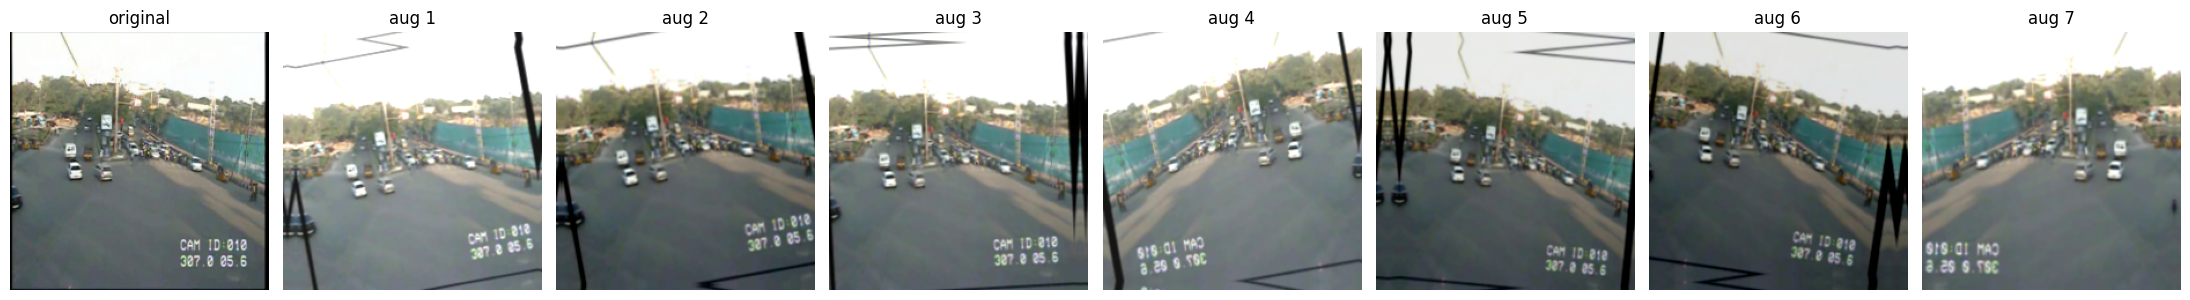

Batch tensor shapes: (16, 224, 224, 3) (16, 1) | pixel range: 0.0 - 255.0


In [ ]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03, fill_mode="reflect"),            # 0.03 * 360 deg = about +-11 deg
    layers.RandomZoom(0.10, fill_mode="reflect"),
    layers.RandomTranslation(0.05, 0.05, fill_mode="reflect"),
    layers.RandomBrightness(0.15, value_range=(0, 255)),
    layers.RandomContrast(0.15),
], name="augmentation")

def augment_batch(x, y):
    x = augmenter(x, training=True)
    return tf.clip_by_value(x, 0.0, 255.0), y

def make_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(augment_batch, num_parallel_calls=AUTOTUNE)    # augmentation ONLY for training
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)   # no augmentation, no shuffle
test_ds  = make_dataset(test_paths,  test_labels,  training=False)   # no augmentation, no shuffle

# Visual check: one training image augmented 7 times (first = original)
img0, _ = load_image(train_paths[0], train_labels[0])
fig, axes = plt.subplots(1, 8, figsize=(22, 3))
axes[0].imshow(img0.numpy().astype("uint8")); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 8):
    a = augmenter(img0[None], training=True)[0]
    axes[i].imshow(np.clip(a.numpy(), 0, 255).astype("uint8")); axes[i].set_title(f"aug {i}"); axes[i].axis("off")
plt.tight_layout(); plt.show()

xb, yb = next(iter(train_ds))
print("Batch tensor shapes:", xb.shape, yb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))

In [ ]:
def _hw(x):
    h = x.shape[1] if x.shape[1] is not None else tf.shape(x)[1]
    w = x.shape[2] if x.shape[2] is not None else tf.shape(x)[2]
    return h, w

@keras.utils.register_keras_serializable(package="CRFNet")
class ConvBNAct(layers.Layer):                                    # STANDARD
    def __init__(self, filters, kernel_size=3, strides=1, dilation_rate=1, activation="swish", **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size, self.strides = filters, kernel_size, strides
        self.dilation_rate, self.activation_name = dilation_rate, activation
        self.conv = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                                  dilation_rate=dilation_rate, use_bias=False)
        self.bn = layers.BatchNormalization()
        self.act = layers.Activation(activation)

    def call(self, x, training=False):
        return self.act(self.bn(self.conv(x), training=training))

    def get_config(self):
        cfg = super().get_config()
        cfg.update(filters=self.filters, kernel_size=self.kernel_size, strides=self.strides,
                   dilation_rate=self.dilation_rate, activation=self.activation_name)
        return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class SharedCNNBackbone(layers.Layer):                            # PROPOSED (custom, lightweight)
    def __init__(self, low_filters=(24, 32), mid_filters=64, high_filters=96, mid_dropout=0.05, **kwargs):
        super().__init__(**kwargs)
        self.low_filters, self.mid_filters, self.high_filters = tuple(low_filters), mid_filters, high_filters
        self.mid_dropout = mid_dropout
        l1, l2 = low_filters
        # low level: 224 -> 112 -> 56
        self.low = [ConvBNAct(l1, 3, 2), ConvBNAct(l1, 3, 1), ConvBNAct(l2, 3, 2), ConvBNAct(l2, 3, 1)]
        # mid level: 56 -> 28
        self.mid = [ConvBNAct(mid_filters, 3, 2), ConvBNAct(mid_filters, 3, 1)]
        self.mid_drop = layers.SpatialDropout2D(mid_dropout)
        # high level: 28 -> 14
        self.high = [ConvBNAct(high_filters, 3, 2), ConvBNAct(high_filters, 3, 1), ConvBNAct(high_filters, 3, 1)]

    def call(self, x, training=False, return_intermediate=False):
        for blk in self.low:
            x = blk(x, training=training)
        low = x
        for blk in self.mid:
            x = blk(x, training=training)
        x = self.mid_drop(x, training=training)
        mid = x
        for blk in self.high:
            x = blk(x, training=training)
        if return_intermediate:
            return x, {"low": low, "mid": mid, "high": x}
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update(low_filters=list(self.low_filters), mid_filters=self.mid_filters,
                   high_filters=self.high_filters, mid_dropout=self.mid_dropout)
        return cfg

# quick shape test
_t = SharedCNNBackbone()
_f, _inter = _t(tf.zeros((2, IMG_SIZE, IMG_SIZE, 3)), return_intermediate=True)
print({k: tuple(v.shape) for k, v in _inter.items()})

{'low': (2, 56, 56, 32), 'mid': (2, 28, 28, 64), 'high': (2, 14, 14, 96)}


In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class AppearanceFeatureExtraction(layers.Layer):                  # PROPOSED
    def __init__(self, channels=64, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.block = ConvBNAct(channels, 3)                       # Conv -> BN -> Swish
        self.out = layers.Conv2D(channels, 1, padding="same")     # final 1x1 conv

    def call(self, x, training=False):
        return self.out(self.block(x, training=training))

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class SpatialFeatureExtraction(layers.Layer):                     # PROPOSED
    def __init__(self, channels=64, dilations=(1, 2, 4), **kwargs):
        super().__init__(**kwargs)
        self.channels, self.dilations = channels, tuple(dilations)
        self.proj = ConvBNAct(channels, 1)                        # mixes features + coordinates
        self.dw = [layers.DepthwiseConv2D(3, padding="same", dilation_rate=d, use_bias=False) for d in dilations]
        self.dw_bn = [layers.BatchNormalization() for _ in dilations]
        self.act = layers.Activation("swish")
        self.neigh_pool = layers.AveragePooling2D(3, strides=1, padding="same")   # local neighbourhood view
        self.mix = ConvBNAct(channels, 1)
        self.spatial_att = layers.Conv2D(1, 7, padding="same", activation="sigmoid")

    @staticmethod
    def coordinate_channels(x):
        h, w = _hw(x)
        b = tf.shape(x)[0]
        ys = tf.linspace(-1.0, 1.0, h)
        xs = tf.linspace(-1.0, 1.0, w)
        yy, xx = tf.meshgrid(ys, xs, indexing="ij")
        coords = tf.stack([yy, xx], axis=-1)[None]                # (1, H, W, 2)
        return tf.tile(coords, [b, 1, 1, 1])

    def call(self, x, training=False):
        coords = tf.cast(self.coordinate_channels(x), x.dtype)
        z = self.proj(tf.concat([x, coords], axis=-1), training=training)
        branches = [self.act(bn(dw(z), training=training)) for dw, bn in zip(self.dw, self.dw_bn)]
        branches.append(self.neigh_pool(z))
        y = self.mix(tf.concat(branches, axis=-1), training=training)
        avg = tf.reduce_mean(y, axis=-1, keepdims=True)
        mx = tf.reduce_max(y, axis=-1, keepdims=True)
        att = self.spatial_att(tf.concat([avg, mx], axis=-1))     # (B, H, W, 1) "where to look"
        return y * att + z                                        # residual keeps position information

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels, dilations=list(self.dilations)); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class StructuralFeatureExtraction(layers.Layer):                  # PROPOSED
    def __init__(self, channels=64, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        mid = channels // 2
        self.reduce = ConvBNAct(mid, 1)
        self.path3 = ConvBNAct(mid, 3)                            # normal scale
        self.path5 = ConvBNAct(mid, 3, dilation_rate=2)           # larger scale
        self.blur = layers.AveragePooling2D(3, strides=1, padding="same")
        self.edge_conv = ConvBNAct(mid, 3)                        # edge / boundary path
        self.fuse = ConvBNAct(channels, 1)
        self.shortcut = layers.Conv2D(channels, 1, padding="same")

    def call(self, x, training=False):
        r = self.reduce(x, training=training)
        s3 = self.path3(r, training=training)
        s5 = self.path5(r, training=training)
        edges = x - self.blur(x)                                  # high-pass: keeps boundaries
        e = self.edge_conv(edges, training=training)
        y = self.fuse(tf.concat([s3, s5, e], axis=-1), training=training)
        return y + self.shortcut(x)

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class CollisionRelationExtraction(layers.Layer):                  # PROPOSED
    def __init__(self, channels=64, heads=4, key_dim=16, attn_dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.heads, self.key_dim, self.attn_dropout = channels, heads, key_dim, attn_dropout
        assert channels % heads == 0
        self.val_dim = channels // heads
        self.project = ConvBNAct(channels, 1)                     # feature projection
        self.q = layers.Conv2D(heads * key_dim, 1, use_bias=False)
        self.k = layers.Conv2D(heads * key_dim, 1, use_bias=False)
        self.v = layers.Conv2D(heads * self.val_dim, 1, use_bias=False)
        self.out = layers.Conv2D(channels, 1)
        self.drop = layers.Dropout(attn_dropout)
        self.fuse = ConvBNAct(channels, 1)

    def _split_heads(self, t, d, n):
        t = tf.reshape(t, [-1, n, self.heads, d])                 # (B, N, heads, d)
        return tf.transpose(t, [0, 2, 1, 3])                      # (B, heads, N, d)

    def call(self, streams, training=False):
        x = tf.concat(list(streams), axis=-1)                     # appearance + spatial + structural
        p = self.project(x, training=training)                    # (B, H, W, C)
        h, w = _hw(p)
        n = h * w
        q = self._split_heads(self.q(p), self.key_dim, n)
        k = self._split_heads(self.k(p), self.key_dim, n)
        v = self._split_heads(self.v(p), self.val_dim, n)
        logits = tf.matmul(q, k, transpose_b=True) * (self.key_dim ** -0.5)   # (B, heads, N, N) pairwise relations
        attn = tf.nn.softmax(logits, axis=-1)
        attn = self.drop(attn, training=training)
        ctx = tf.matmul(attn, v)                                  # (B, heads, N, d)
        ctx = tf.reshape(tf.transpose(ctx, [0, 2, 1, 3]), [-1, h, w, self.heads * self.val_dim])
        rel = self.out(ctx)                                       # related information for each cell
        return self.fuse(tf.concat([p, rel, p * rel], axis=-1), training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(channels=self.channels, heads=self.heads, key_dim=self.key_dim, attn_dropout=self.attn_dropout)
        return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class CollisionRelationFusion(layers.Layer):                      # PROPOSED
    def __init__(self, num_streams, channels=64, **kwargs):
        super().__init__(**kwargs)
        self.num_streams, self.channels = num_streams, channels
        self.projs = [ConvBNAct(channels, 1) for _ in range(num_streams)]
        self.score_hidden = layers.Dense(channels, activation="swish")
        self.score_out = layers.Dense(num_streams)
        self.mix = ConvBNAct(channels, 1)
        self.out_bn = layers.BatchNormalization()
        self.act = layers.Activation("swish")

    def project_and_weight(self, streams, training=False):
        P = [proj(s, training=training) for proj, s in zip(self.projs, streams)]
        desc = tf.concat([tf.reduce_mean(p, axis=[1, 2]) for p in P], axis=-1)       # (B, S*C)
        w = tf.nn.softmax(self.score_out(self.score_hidden(desc)), axis=-1)          # (B, S) learned importance
        return P, w

    def call(self, streams, training=False):
        P, w = self.project_and_weight(streams, training=training)
        stack = tf.stack(P, axis=1)                                                  # (B, S, H, W, C)
        weighted = tf.reduce_sum(stack * w[:, :, None, None, None], axis=1)          # (B, H, W, C)
        mixed = self.mix(tf.concat(P, axis=-1), training=training)
        return self.act(self.out_bn(weighted + mixed, training=training))

    def get_config(self):
        cfg = super().get_config(); cfg.update(num_streams=self.num_streams, channels=self.channels); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class AttentionFusionGate(layers.Layer):                          # PROPOSED
    def __init__(self, channels=64, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.reduction = channels, reduction
        self.fc1 = layers.Dense(max(channels // reduction, 8), activation="swish")
        self.fc2 = layers.Dense(channels, activation="sigmoid", bias_initializer=keras.initializers.Constant(2.0))
        self.spatial = layers.Conv2D(1, 7, padding="same", activation="sigmoid",
                                     bias_initializer=keras.initializers.Constant(2.0))

    def call(self, x, training=False):
        ch_gate = self.fc2(self.fc1(tf.reduce_mean(x, axis=[1, 2])))[:, None, None, :]   # (B,1,1,C) which features
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx = tf.reduce_max(x, axis=-1, keepdims=True)
        sp_gate = self.spatial(tf.concat([avg, mx], axis=-1))                            # (B,H,W,1) where
        return x * ch_gate * sp_gate

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels, reduction=self.reduction); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class FeatureRefinement(layers.Layer):                            # PROPOSED
    def __init__(self, channels=64, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.dropout_rate = channels, dropout
        self.dw = layers.DepthwiseConv2D(3, padding="same", use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.pw = layers.Conv2D(channels, 1, use_bias=False)
        self.bn2 = layers.BatchNormalization()
        self.act = layers.Activation("swish")
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=False):
        y = self.act(self.bn1(self.dw(x), training=training))
        y = self.bn2(self.pw(y), training=training)
        return self.drop(self.act(y + x), training=training)

    def get_config(self):
        cfg = super().get_config(); cfg.update(channels=self.channels, dropout=self.dropout_rate); return cfg

In [ ]:
@keras.utils.register_keras_serializable(package="CRFNet")
class CRFNet(keras.Model):
    def __init__(self, use_appearance=True, use_spatial=True, use_structural=True, use_relation=True,
                 use_attention=True, use_refinement=True, channels=64, head_units=64, head_dropout=0.4, **kwargs):
        super().__init__(**kwargs)
        assert use_appearance or use_spatial or use_structural, "At least one feature branch is required."
        self.flags = dict(use_appearance=use_appearance, use_spatial=use_spatial, use_structural=use_structural,
                          use_relation=use_relation, use_attention=use_attention, use_refinement=use_refinement,
                          channels=channels, head_units=head_units, head_dropout=head_dropout)
        self.rescale = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")                     # STANDARD
        self.backbone = SharedCNNBackbone(name="shared_cnn_backbone")                          # PROPOSED
        self.appearance = AppearanceFeatureExtraction(channels, name="appearance") if use_appearance else None
        self.spatial = SpatialFeatureExtraction(channels, name="spatial") if use_spatial else None
        self.structural = StructuralFeatureExtraction(channels, name="structural") if use_structural else None
        self.relation = CollisionRelationExtraction(channels, name="collision_relation") if use_relation else None
        self.stream_names = ([n for n, u in (("appearance", use_appearance), ("spatial", use_spatial),
                                              ("structural", use_structural)) if u]
                             + (["collision_relation"] if use_relation else []))
        self.fusion = CollisionRelationFusion(len(self.stream_names), channels, name="relation_fusion")
        self.attention = AttentionFusionGate(channels, name="attention_gate") if use_attention else None
        self.refinement = FeatureRefinement(channels, name="feature_refinement") if use_refinement else None
        # ---- standard head ----
        self.gap = layers.GlobalAveragePooling2D(name="global_avg_pool")                       # STANDARD
        self.fc = layers.Dense(head_units, use_bias=False, name="mlp_dense")
        self.fc_bn = layers.BatchNormalization(name="mlp_bn")
        self.fc_act = layers.Activation("relu")
        self.fc_drop = layers.Dropout(head_dropout)
        self.out = layers.Dense(1, activation="sigmoid", name="accident_probability")

    def _streams(self, x, training=False, trace=None):
        def log(name, t):
            if trace is not None:
                trace.append((name, tuple(t.shape)))
        log("Input image", x)
        x = self.rescale(x); log("Rescaling (0-1)", x)
        feat = self.backbone(x, training=training); log("Shared CNN Backbone", feat)
        base = []
        if self.appearance is not None:
            a = self.appearance(feat, training=training); base.append(a); log("Appearance Feature Extraction", a)
        if self.spatial is not None:
            s = self.spatial(feat, training=training); base.append(s); log("Spatial Feature Extraction", s)
        if self.structural is not None:
            t = self.structural(feat, training=training); base.append(t); log("Structural Feature Extraction", t)
        streams = list(base)
        if self.relation is not None:
            r = self.relation(base, training=training); streams.append(r); log("Collision Relation Extraction", r)
        return streams

    def _forward(self, x, training=False, trace=None):
        def log(name, t):
            if trace is not None:
                trace.append((name, tuple(t.shape)))
        streams = self._streams(x, training, trace)
        y = self.fusion(streams, training=training); log("Collision Relation Fusion", y)
        if self.attention is not None:
            y = self.attention(y, training=training); log("Attention Fusion Gate", y)
        if self.refinement is not None:
            y = self.refinement(y, training=training); log("Feature Refinement", y)
        y = self.gap(y); log("Global Average Pooling", y)
        y = self.fc_drop(self.fc_act(self.fc_bn(self.fc(y), training=training)), training=training)
        y = self.out(y); log("MLP Classifier -> P(Accident)", y)
        return y

    def call(self, x, training=False):
        return self._forward(x, training)

    def trace_shapes(self, x):
        trace = []
        self._forward(x, False, trace)
        return trace

    def fusion_weights(self, x):
        """Learned importance of every stream for each image: (B, num_streams)."""
        streams = self._streams(x, False)
        _, w = self.fusion.project_and_weight(streams, False)
        return w

    def get_config(self):
        cfg = super().get_config(); cfg.update(self.flags); return cfg

def count_params(model):
    trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    non_trainable = int(sum(np.prod(w.shape) for w in model.non_trainable_weights))
    return trainable + non_trainable, trainable, non_trainable

In [ ]:
ARCH_TEXT = """
Input
 |
Shared CNN Backbone
 |
 +-- Appearance Feature Extraction
 +-- Spatial Feature Extraction
 +-- Structural Feature Extraction
             |
    Collision Relation Extraction
             |
    Collision Relation Fusion   (fuses appearance + spatial + structural + relation)
             |
      Attention Fusion Gate
             |
      Feature Refinement
             |
    Global Average Pooling
             |
        MLP Classifier
             |
 Accident / Non-Accident
"""
print(ARCH_TEXT)

def make_metrics():
    return [keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")]

def compile_model(model):
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=INIT_LR, weight_decay=WEIGHT_DECAY),
                  loss="binary_crossentropy", metrics=make_metrics())
    return model

def build_crfnet(seed=SEED, **flags):
    set_seed(seed)
    m = CRFNet(**flags)
    m(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))        # builds all weights
    return compile_model(m)

crfnet = build_crfnet(name="CRFNet")
crfnet.summary()

total, trainable, non_trainable = count_params(crfnet)
print(f"\nTotal parameters        : {total:,}")
print(f"Trainable parameters    : {trainable:,}")
print(f"Non-trainable parameters: {non_trainable:,}  (BatchNorm moving mean/variance)")
print(f"Approx. size (float32)  : {total * 4 / 1024**2:.2f} MB")

print("\nParameters per module:")
mod_rows = [{"module": l.name, "parameters": l.count_params()} for l in crfnet.layers if l.count_params() > 0]
display(pd.DataFrame(mod_rows))

print("\nTENSOR FLOW (B = batch size):")
for name, shape in crfnet.trace_shapes(tf.zeros((2, IMG_SIZE, IMG_SIZE, 3))):
    print(f"  {name:<34s}-> {('B',) + shape[1:]}")
print("""
How tensors flow:
  * The backbone shrinks the image 16x (224 -> 14) while growing channels (3 -> 96).
  * Appearance, Spatial and Structural each read the SAME 14x14x96 map and each output 14x14x64.
  * Collision Relation reads the three 64-channel maps (concatenated = 192 channels), projects to 64,
    builds a 196x196 pairwise relation matrix (14*14 = 196 cells) and outputs a 14x14x64 map.
  * Fusion receives 4 maps (appearance, spatial, structural, relation), learns 4 importance weights per image,
    and outputs ONE 14x14x64 map. Attention and Refinement keep the shape 14x14x64.
  * Global Average Pooling averages each of the 64 channels over the 14x14 grid -> a 64-number vector.
  * The MLP turns that vector into one probability.
""")


Input
 |
Shared CNN Backbone
 |
 +-- Appearance Feature Extraction
 +-- Spatial Feature Extraction
 +-- Structural Feature Extraction
             |
    Collision Relation Extraction
             |
    Collision Relation Fusion   (fuses appearance + spatial + structural + relation)
             |
      Attention Fusion Gate
             |
      Feature Refinement
             |
    Global Average Pooling
             |
        MLP Classifier
             |
 Accident / Non-Accident



Model: "CRFNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescale_0_1 (Rescaling)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_cnn_backbone             │ ?                      │       300,552 │
│ (SharedCNNBackbone)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ appearance                      │ ?                      │        59,712 │
│ (AppearanceFeatureExtraction)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial                         │ ?                      │        25,763 │
│ (SpatialFeatureExtraction)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ structural                      │ ?                      │        62,272 │
│ (StructuralFeatureExtraction)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ collision_relation              │ ?                      │        41,536 │
│ (CollisionRelationExtraction)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relation_fusion                 │ ?                      │        51,012 │
│ (CollisionRelationFusion)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_gate                  │ ?                      │         2,227 │
│ (AttentionFusionGate)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_refinement              │ ?                      │         5,184 │
│ (FeatureRefinement)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense (Dense)               │ (1, 64)                │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_bn (BatchNormalization)     │ (1, 64)                │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ accident_probability (Dense)    │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,675 (2.11 MB)

 Trainable params: 549,059 (2.09 MB)

 Non-trainable params: 3,616 (14.12 KB)


Total parameters        : 552,675
Trainable parameters    : 549,059
Non-trainable parameters: 3,616  (BatchNorm moving mean/variance)
Approx. size (float32)  : 2.11 MB

Parameters per module:


,module,parameters
0,shared_cnn_backbone,300552
1,appearance,59712
2,spatial,25763
3,structural,62272
4,collision_relation,41536
5,relation_fusion,51012
6,attention_gate,2227
7,feature_refinement,5184
8,mlp_dense,4096
9,mlp_bn,256



TENSOR FLOW (B = batch size):
  Input image                       -> ('B', 224, 224, 3)
  Rescaling (0-1)                   -> ('B', 224, 224, 3)
  Shared CNN Backbone               -> ('B', 14, 14, 96)
  Appearance Feature Extraction     -> ('B', 14, 14, 64)
  Spatial Feature Extraction        -> ('B', 14, 14, 64)
  Structural Feature Extraction     -> ('B', 14, 14, 64)
  Collision Relation Extraction     -> ('B', 14, 14, 64)
  Collision Relation Fusion         -> ('B', 14, 14, 64)
  Attention Fusion Gate             -> ('B', 14, 14, 64)
  Feature Refinement                -> ('B', 14, 14, 64)
  Global Average Pooling            -> ('B', 64)
  MLP Classifier -> P(Accident)     -> ('B', 1)

How tensors flow:
  * The backbone shrinks the image 16x (224 -> 14) while growing channels (3 -> 96).
  * Appearance, Spatial and Structural each read the SAME 14x14x96 map and each output 14x14x64.
  * Collision Relation reads the three 64-channel maps (concatenated = 192 channels), projects to 6

In [ ]:
def train_model(model, tag, epochs=MAX_EPOCHS, verbose=2):
    ckpt_path = os.path.join(CKPT_DIR, f"{tag}.weights.h5")
    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True,
                                        save_weights_only=True, verbose=0),
    ]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, class_weight=class_weight,
                     callbacks=cbs, verbose=verbose)
    train_time = time.time() - t0
    model.load_weights(ckpt_path)                    # make sure the BEST-val-loss weights are used
    return hist, train_time, ckpt_path

crfnet = build_crfnet(name="CRFNet")
crf_hist, crf_train_time, crf_ckpt = train_model(crfnet, "crfnet_full")
print(f"\nTraining time: {crf_train_time/60:.1f} min for {len(crf_hist.history['loss'])} epochs")

Epoch 1/60
50/50 - 121s - 2s/step - accuracy: 0.4874 - auc: 0.5030 - loss: 0.7762 - precision: 0.4639 - recall: 0.6243 - val_accuracy: 0.5306 - val_auc: 0.5000 - val_loss: 0.6917 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/60
50/50 - 11s - 229ms/step - accuracy: 0.5000 - auc: 0.5415 - loss: 0.7570 - precision: 0.4746 - recall: 0.6568 - val_accuracy: 0.5306 - val_auc: 0.5000 - val_loss: 0.6914 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/60
50/50 - 12s - 235ms/step - accuracy: 0.5341 - auc: 0.5464 - loss: 0.7831 - precision: 0.5010 - recall: 0.6649 - val_accuracy: 0.5306 - val_auc: 0.5000 - val_loss: 0.6927 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/60
50/50 - 12s - 236ms/step - accuracy: 0.5657 - auc: 0.5873 - loss: 0.7299 - precision: 0.5274 - recall: 0.6757 - val_accuracy: 0.5306 - val_auc: 0.4783 - val_loss: 0.6948 - val_precision: 0.0000e+00 - val_r

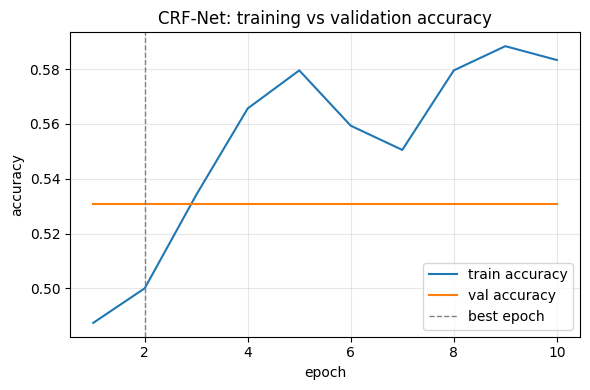

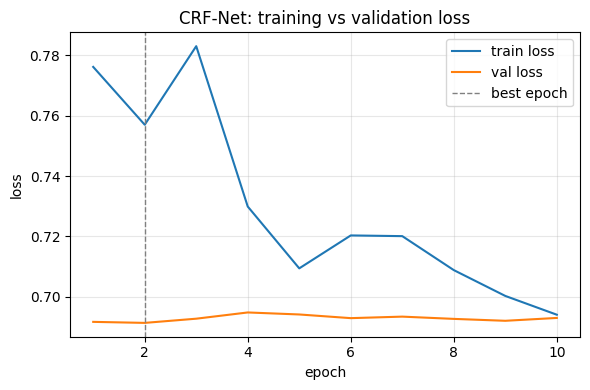

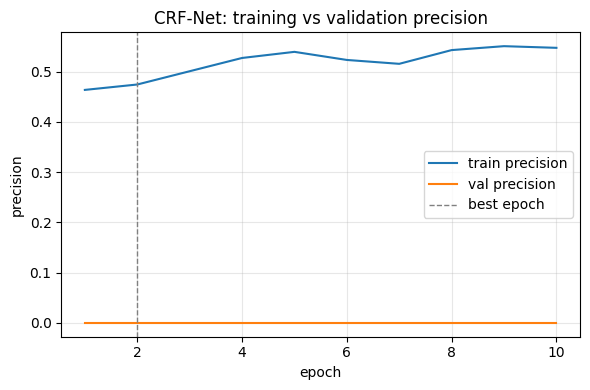

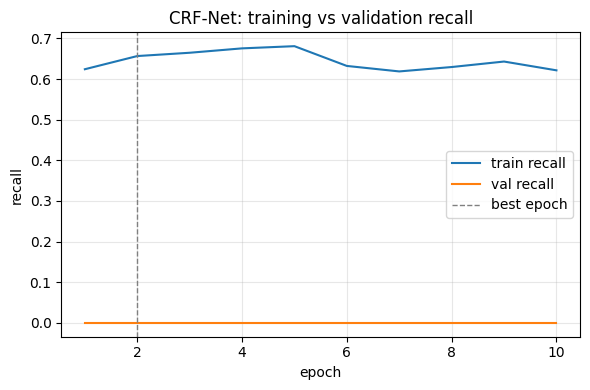

Best epoch (lowest val_loss): 2
  best validation loss     : 0.6914
  validation accuracy      : 0.5306
  validation precision     : 0.0000
  validation recall        : 0.0000


In [ ]:
def history_to_df(history):
    df = pd.DataFrame(history.history)
    df.insert(0, "epoch", np.arange(1, len(df) + 1))
    return df

def plot_metric(df, metric, title, fname=None, ax=None):
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df["epoch"], df[metric], label=f"train {metric}")
    ax.plot(df["epoch"], df["val_" + metric], label=f"val {metric}")
    ax.axvline(int(df["val_loss"].idxmin()) + 1, color="gray", ls="--", lw=1, label="best epoch")
    ax.set_xlabel("epoch"); ax.set_ylabel(metric); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    if own:
        plt.tight_layout()
        if fname:
            plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=200)
        plt.show()

crf_hist_df = history_to_df(crf_hist)
plot_metric(crf_hist_df, "accuracy", "CRF-Net: training vs validation accuracy", "accuracy_curve.png")
plot_metric(crf_hist_df, "loss", "CRF-Net: training vs validation loss", "loss_curve.png")
plot_metric(crf_hist_df, "precision", "CRF-Net: training vs validation precision", "precision_curve.png")
plot_metric(crf_hist_df, "recall", "CRF-Net: training vs validation recall", "recall_curve.png")

best_i = int(crf_hist_df["val_loss"].idxmin())
print(f"Best epoch (lowest val_loss): {best_i + 1}")
print(f"  best validation loss     : {crf_hist_df.loc[best_i, 'val_loss']:.4f}")
print(f"  validation accuracy      : {crf_hist_df.loc[best_i, 'val_accuracy']:.4f}")
print(f"  validation precision     : {crf_hist_df.loc[best_i, 'val_precision']:.4f}")
print(f"  validation recall        : {crf_hist_df.loc[best_i, 'val_recall']:.4f}")

In [ ]:
def compute_metrics(y_true, probs, thr=0.5):
    y_pred = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": thr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),            # = sensitivity
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "roc_auc": roc_auc_score(y_true, probs),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

def predict_probs(model, ds):
    return model.predict(ds, verbose=0).ravel()      # datasets are not shuffled -> same order as the label arrays

def show_metrics(m, title):
    print(f"--- {title} (threshold = {m['threshold']:.2f}) ---")
    for k in ("accuracy", "precision", "recall", "f1", "specificity", "roc_auc"):
        print(f"  {k:<12s}: {m[k]:.4f}")
    print(f"  TN={m['TN']}  FP={m['FP']}  FN={m['FN']}  TP={m['TP']}")

In [ ]:
crf_val_probs = predict_probs(crfnet, val_ds)
crf_val_m = compute_metrics(val_labels, crf_val_probs, 0.5)
show_metrics(crf_val_m, "CRF-Net - VALIDATION")

--- CRF-Net - VALIDATION (threshold = 0.50) ---
  accuracy    : 0.5306
  precision   : 0.0000
  recall      : 0.0000
  f1          : 0.0000
  specificity : 1.0000
  roc_auc     : 0.6131
  TN=52  FP=0  FN=46  TP=0


In [ ]:
crf_test_probs = predict_probs(crfnet, test_ds)
crf_test_m = compute_metrics(test_labels, crf_test_probs, 0.5)
show_metrics(crf_test_m, "CRF-Net - TEST")
print("Sensitivity (= recall):", round(crf_test_m["recall"], 4), "| Specificity:", round(crf_test_m["specificity"], 4))

print("\nClassification report (TEST, threshold 0.5):")
report_05 = classification_report(test_labels, (crf_test_probs >= 0.5).astype(int),
                                  target_names=["Non-Accident", "Accident"], digits=4)
print(report_05)   # includes macro avg and weighted avg

--- CRF-Net - TEST (threshold = 0.50) ---
  accuracy    : 0.5300
  precision   : 0.0000
  recall      : 0.0000
  f1          : 0.0000
  specificity : 1.0000
  roc_auc     : 0.5399
  TN=53  FP=0  FN=47  TP=0
Sensitivity (= recall): 0.0 | Specificity: 1.0

Classification report (TEST, threshold 0.5):
              precision    recall  f1-score   support

Non-Accident     0.5300    1.0000    0.6928        53
    Accident     0.0000    0.0000    0.0000        47

    accuracy                         0.5300       100
   macro avg     0.2650    0.5000    0.3464       100
weighted avg     0.2809    0.5300    0.3672       100



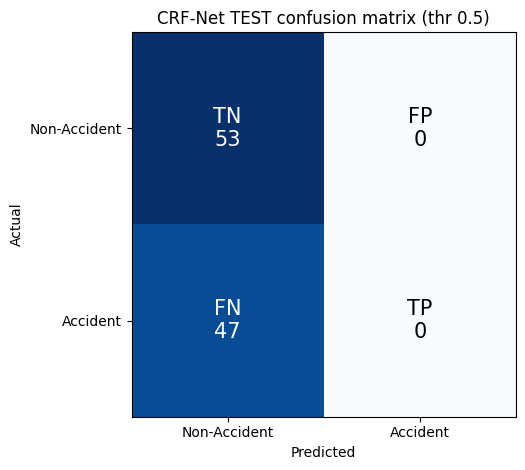

TN=53  FP=0  FN=47  TP=0


In [ ]:
def plot_confusion(y, p, thr, fname, title):
    cm = confusion_matrix(y, (p >= thr).astype(int), labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.4, 4.8))
    ax.imshow(cm, cmap="Blues")
    labels4 = np.array([["TN", "FP"], ["FN", "TP"]])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels4[i, j]}\n{cm[i, j]}", ha="center", va="center", fontsize=15,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Accident", "Accident"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Accident", "Accident"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=200); plt.show()
    return cm

cm05 = plot_confusion(test_labels, crf_test_probs, 0.5, "confusion_matrix.png", "CRF-Net TEST confusion matrix (thr 0.5)")
print(f"TN={cm05[0,0]}  FP={cm05[0,1]}  FN={cm05[1,0]}  TP={cm05[1,1]}")

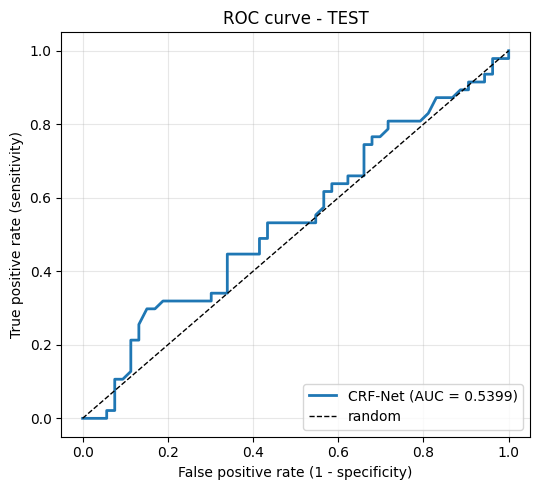

ROC-AUC (test): 0.5399


In [ ]:
fpr, tpr, _ = roc_curve(test_labels, crf_test_probs)
auc_test = roc_auc_score(test_labels, crf_test_probs)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, label=f"CRF-Net (AUC = {auc_test:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False positive rate (1 - specificity)"); plt.ylabel("True positive rate (sensitivity)")
plt.title("ROC curve - TEST"); plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curve.png"), dpi=200); plt.show()
print("ROC-AUC (test):", round(auc_test, 4))

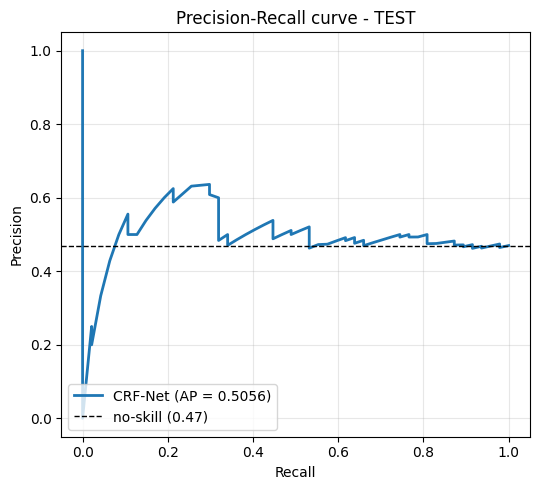

Average precision (test): 0.5056


In [ ]:
prec_c, rec_c, _ = precision_recall_curve(test_labels, crf_test_probs)
ap_test = average_precision_score(test_labels, crf_test_probs)
plt.figure(figsize=(5.5, 5))
plt.plot(rec_c, prec_c, lw=2, label=f"CRF-Net (AP = {ap_test:.4f})")
plt.axhline(test_labels.mean(), color="k", ls="--", lw=1, label=f"no-skill ({test_labels.mean():.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve - TEST")
plt.legend(loc="lower left"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "precision_recall_curve.png"), dpi=200); plt.show()
print("Average precision (test):", round(ap_test, 4))

VALIDATION (used to choose the threshold):


,split,threshold,precision,recall,f1,specificity,accuracy,TN,FP,FN,TP
0,validation,0.1,0.4694,1.0,0.6389,0.0,0.4694,0,52,0,46
1,validation,0.2,0.4694,1.0,0.6389,0.0,0.4694,0,52,0,46
2,validation,0.3,0.4694,1.0,0.6389,0.0,0.4694,0,52,0,46
3,validation,0.4,0.4694,1.0,0.6389,0.0,0.4694,0,52,0,46
4,validation,0.5,0.0000,0.0,0.0000,1.0,0.5306,52,0,46,0
5,validation,0.6,0.0000,0.0,0.0000,1.0,0.5306,52,0,46,0
6,validation,0.7,0.0000,0.0,0.0000,1.0,0.5306,52,0,46,0
7,validation,0.8,0.0000,0.0,0.0000,1.0,0.5306,52,0,46,0
8,validation,0.9,0.0000,0.0,0.0000,1.0,0.5306,52,0,46,0



>>> Selected threshold (best validation F1): 0.4
TEST (report only, not used for selection):


,split,threshold,precision,recall,f1,specificity,accuracy,TN,FP,FN,TP
0,test,0.1,0.47,1.0,0.6395,0.0,0.47,0,53,0,47
1,test,0.2,0.47,1.0,0.6395,0.0,0.47,0,53,0,47
2,test,0.3,0.47,1.0,0.6395,0.0,0.47,0,53,0,47
3,test,0.4,0.47,1.0,0.6395,0.0,0.47,0,53,0,47
4,test,0.5,0.00,0.0,0.0000,1.0,0.53,53,0,47,0
5,test,0.6,0.00,0.0,0.0000,1.0,0.53,53,0,47,0
6,test,0.7,0.00,0.0,0.0000,1.0,0.53,53,0,47,0
7,test,0.8,0.00,0.0,0.0000,1.0,0.53,53,0,47,0
8,test,0.9,0.00,0.0,0.0000,1.0,0.53,53,0,47,0


--- CRF-Net - TEST with validation-selected threshold 0.4 (threshold = 0.40) ---
  accuracy    : 0.4700
  precision   : 0.4700
  recall      : 1.0000
  f1          : 0.6395
  specificity : 0.0000
  roc_auc     : 0.5399
  TN=0  FP=53  FN=0  TP=47


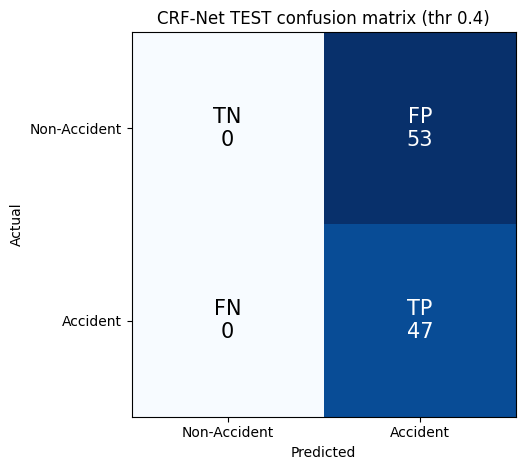

              precision    recall  f1-score   support

Non-Accident     0.0000    0.0000    0.0000        53
    Accident     0.4700    1.0000    0.6395        47

    accuracy                         0.4700       100
   macro avg     0.2350    0.5000    0.3197       100
weighted avg     0.2209    0.4700    0.3005       100



In [ ]:
THRESHOLDS = [round(t, 1) for t in np.arange(0.1, 1.0, 0.1)]

def threshold_table(y, p, split):
    rows = []
    for t in THRESHOLDS:
        m = compute_metrics(y, p, t)
        rows.append({"split": split, "threshold": t, "precision": m["precision"], "recall": m["recall"],
                     "f1": m["f1"], "specificity": m["specificity"], "accuracy": m["accuracy"],
                     "TN": m["TN"], "FP": m["FP"], "FN": m["FN"], "TP": m["TP"]})
    return pd.DataFrame(rows)

def select_threshold(val_table):
    best = val_table["f1"].max()
    cand = val_table[val_table["f1"] >= best - 1e-12].copy()
    cand["dist"] = (cand["threshold"] - 0.5).abs()
    return float(cand.sort_values("dist").iloc[0]["threshold"])

thr_val = threshold_table(val_labels, crf_val_probs, "validation")
thr_test = threshold_table(test_labels, crf_test_probs, "test")
print("VALIDATION (used to choose the threshold):"); display(thr_val.round(4))
BEST_THR = select_threshold(thr_val)
print(f"\n>>> Selected threshold (best validation F1): {BEST_THR}")
print("TEST (report only, not used for selection):"); display(thr_test.round(4))

pd.concat([thr_val, thr_test]).to_csv(os.path.join(RESULTS_DIR, "threshold_analysis.csv"), index=False)

crf_test_m_tuned = compute_metrics(test_labels, crf_test_probs, BEST_THR)
show_metrics(crf_test_m_tuned, f"CRF-Net - TEST with validation-selected threshold {BEST_THR}")
cm_tuned = plot_confusion(test_labels, crf_test_probs, BEST_THR, "confusion_matrix_tuned_threshold.png",
                          f"CRF-Net TEST confusion matrix (thr {BEST_THR})")

report_tuned = classification_report(test_labels, (crf_test_probs >= BEST_THR).astype(int),
                                     target_names=["Non-Accident", "Accident"], digits=4)
print(report_tuned)
with open(os.path.join(RESULTS_DIR, "classification_report.txt"), "w") as f:
    f.write("CRF-Net TEST classification report - threshold 0.5\n" + report_05 +
            f"\n\nCRF-Net TEST classification report - validation-selected threshold {BEST_THR}\n" + report_tuned)

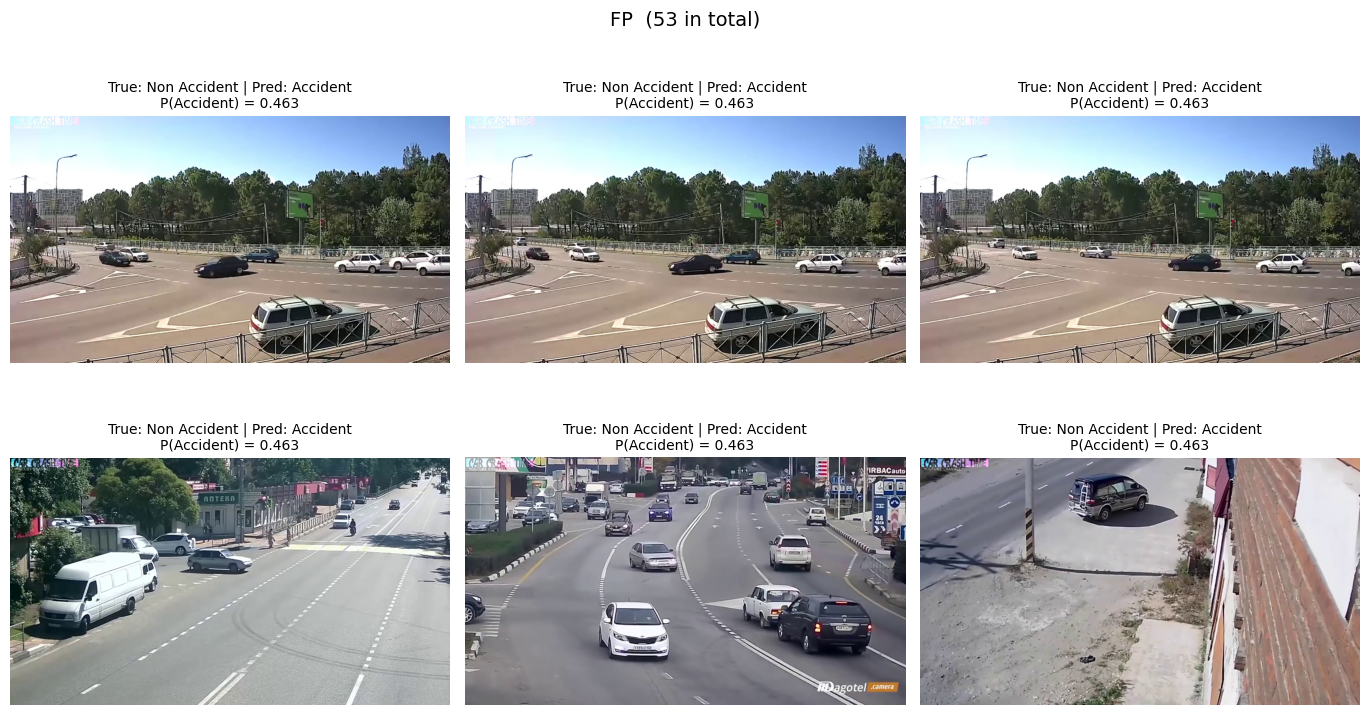

FN: no examples


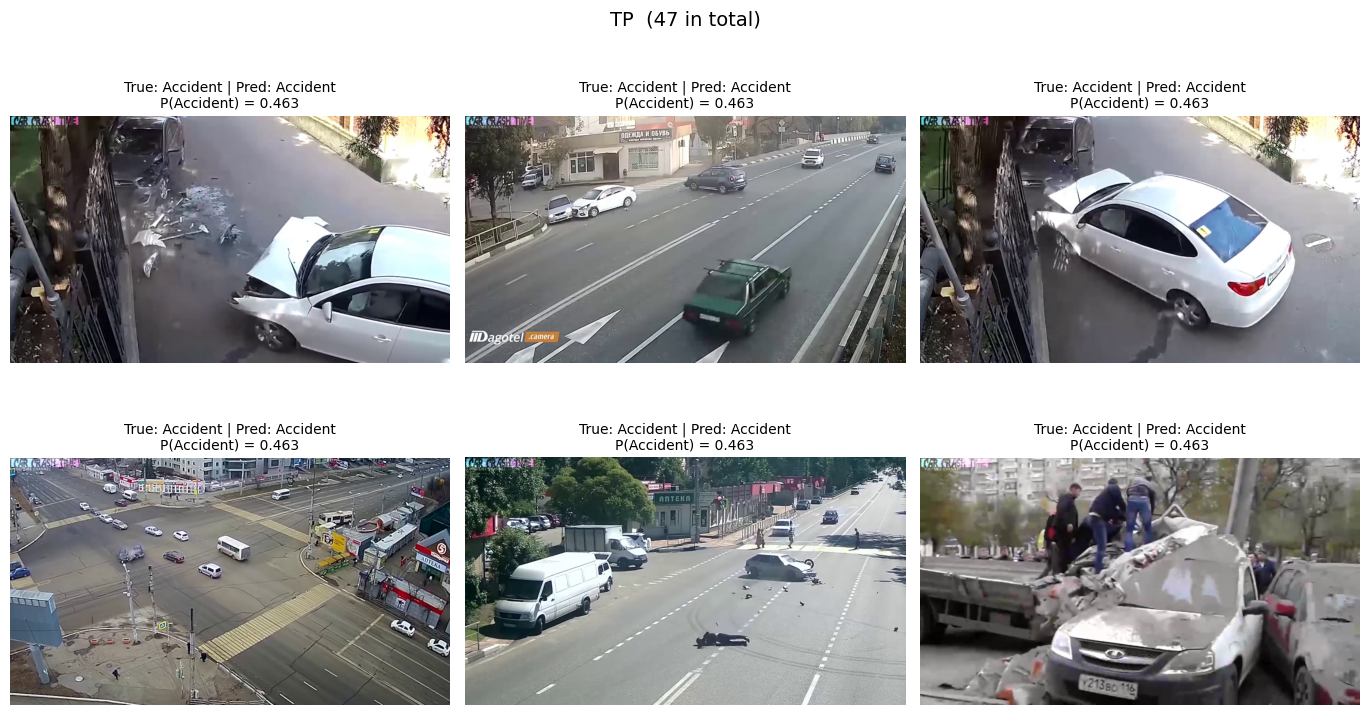

TN: no examples


,file,true_label,pred_label,prob_accident,outcome
0,5_23.jpg,0,1,0.463002,FP
28,test29_19.jpg,0,1,0.463004,FP
29,test29_3.jpg,0,1,0.463004,FP
30,test29_6.jpg,0,1,0.463006,FP
31,test29_7.jpg,0,1,0.463006,FP
32,test3_12.jpg,0,1,0.463002,FP
33,test3_18.jpg,0,1,0.463003,FP
34,test3_21.jpg,0,1,0.463006,FP
35,test3_40.jpg,0,1,0.463004,FP
36,test4_10.jpg,0,1,0.463004,FP


In [ ]:
def outcome_masks(y, p, thr):
    pred = (p >= thr).astype(int)
    return pred, {"TP": (y == 1) & (pred == 1), "TN": (y == 0) & (pred == 0),
                  "FP": (y == 0) & (pred == 1), "FN": (y == 1) & (pred == 0)}

def show_outcome(paths, y, p, thr, cat, k=6, seed=SEED, save=True):
    pred, masks = outcome_masks(y, p, thr)
    idx = np.where(masks[cat])[0]
    if len(idx) == 0:
        print(f"{cat}: no examples"); return
    if cat in ("FP", "FN"):
        idx = idx[np.argsort(-np.abs(p[idx] - thr))]          # most confident mistakes first
    else:
        idx = np.random.RandomState(seed).permutation(idx)
    idx = idx[:k]
    cols = min(3, len(idx)); rows = int(math.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.0 * rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), idx):
        ax.imshow(Image.open(paths[i]).convert("RGB"))
        ax.set_title(f"True: {LABEL_TO_NAME[int(y[i])]} | Pred: {LABEL_TO_NAME[int(pred[i])]}\nP(Accident) = {p[i]:.3f}", fontsize=10)
    fig.suptitle(f"{cat}  ({int(masks[cat].sum())} in total)", fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(RESULTS_DIR, "misclassified_images", f"examples_{cat}.png"), dpi=150)
    plt.show()

for cat in ("FP", "FN", "TP", "TN"):
    show_outcome(test_paths, test_labels, crf_test_probs, BEST_THR, cat)

def export_errors(paths, y, p, thr):
    pred, masks = outcome_masks(y, p, thr)
    root = os.path.join(RESULTS_DIR, "misclassified_images")
    for cat in ("FP", "FN"):
        d = os.path.join(root, cat); shutil.rmtree(d, ignore_errors=True); os.makedirs(d)
        for i in np.where(masks[cat])[0]:
            shutil.copy(paths[i], os.path.join(d, f"p{p[i]:.3f}_{Path(paths[i]).name}"))
    table = pd.DataFrame({"file": [Path(x).name for x in paths], "true_label": y, "pred_label": pred,
                          "prob_accident": p})
    table["outcome"] = np.select(
    [masks[c] for c in ["TP", "TN", "FP", "FN"]],
    ["TP", "TN", "FP", "FN"],
    default="Unknown"
)
    table.to_csv(os.path.join(RESULTS_DIR, "test_predictions.csv"), index=False)
    return table

crf_pred_table = export_errors(test_paths, test_labels, crf_test_probs, BEST_THR)
display(crf_pred_table[crf_pred_table["outcome"].isin(["FP", "FN"])].sort_values("outcome"))

In [ ]:
W = np.concatenate([crfnet.fusion_weights(xb).numpy() for xb, _ in test_ds])
fw = pd.DataFrame(W, columns=crfnet.stream_names)
fw["true_class"] = [LABEL_TO_NAME[int(l)] for l in test_labels]
print("Mean learned stream importance on the TEST set (each row sums to 1):")
display(fw.groupby("true_class").mean().round(4))

Mean learned stream importance on the TEST set (each row sums to 1):


,appearance,spatial,structural,collision_relation
true_class,,,,
Accident,0.2533,0.2567,0.2506,0.2395
Non Accident,0.2533,0.2567,0.2506,0.2395


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 28, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 250,209 (977.38 KB)

 Trainable params: 249,505 (974.63 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
50/50 - 42s - 834ms/step - accuracy: 0.5290 - auc: 0.5324 - loss: 0.7530 - precision: 0.4967 - recall: 0.6108 - val_accuracy: 0.4694 - val_auc: 0.5000 - val_loss: 0.7001 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/60
50/50 - 17s - 335ms/step - accuracy: 0.5177 - auc: 0.5446 - loss: 0.7192 - precision: 0.4847 - recall: 0.5135 - val_accuracy: 0.4694 - val_auc: 0.6200 - val_loss: 0.6925 - val_precision: 0.3750 - val_recall: 0.1957 - learning_rate: 1.0000e-04
Epoch 3/60
50/50 - 11s - 223ms/step - accuracy: 0.5644 - auc: 0.5994 - loss: 0.6890 - precision: 0.5287 - recall: 0.6216 - val_accuracy: 0.5306 - val_auc: 0.5205 - val_loss: 0.6921 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/60
50/50 - 12s - 240ms/step - accuracy: 0.5581 - auc: 0.5825 - loss: 0.6928 - precision: 0.5281 - recall: 0.5081 - val_accuracy: 0.5306 - val_auc: 0.5238 - val_loss: 0.6934 - val_precision: 0.0000e+00 - val_recall: 0.0000e

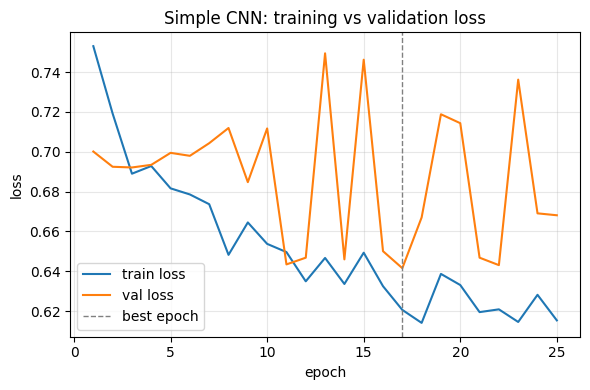

In [ ]:
def build_baseline(seed=SEED):
    set_seed(seed)
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1.0 / 255.0)(inp)
    for f in (32, 64, 128, 128):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return compile_model(keras.Model(inp, out, name="SimpleCNN"))

baseline = build_baseline()
baseline.summary()
base_hist, base_train_time, base_ckpt = train_model(baseline, "baseline_simple_cnn")
base_val_probs = predict_probs(baseline, val_ds)
base_test_probs = predict_probs(baseline, test_ds)
base_test_m = compute_metrics(test_labels, base_test_probs, 0.5)
show_metrics(base_test_m, "Simple CNN - TEST")
plot_metric(history_to_df(base_hist), "loss", "Simple CNN: training vs validation loss")

In [ ]:
VARIANTS = {
    "Full CRF-Net":               {},
    "Without Appearance":         dict(use_appearance=False),
    "Without Spatial":            dict(use_spatial=False),
    "Without Structural":         dict(use_structural=False),
    "Without Collision Relation": dict(use_relation=False),
    "Without Attention":          dict(use_attention=False),
    "Without Refinement":         dict(use_refinement=False),
}
METRIC_COLS = ["accuracy", "precision", "recall", "f1", "specificity", "roc_auc"]

def make_record(name, model, probs, y, train_time, epochs_run, seed):
    m = compute_metrics(y, probs, 0.5)
    total_params, _, _ = count_params(model)
    rec = {"model": name, "seed": seed}
    rec.update({k: m[k] for k in METRIC_COLS})
    rec.update({"TN": m["TN"], "FP": m["FP"], "FN": m["FN"], "TP": m["TP"], "parameters": total_params,
                "train_time_s": round(train_time, 1), "epochs_run": epochs_run})
    return rec

ablation_runs = []
for vname, flags in VARIANTS.items():
    for seed in ABLATION_SEEDS:
        if vname == "Full CRF-Net" and seed == SEED:
            ablation_runs.append(make_record(vname, crfnet, crf_test_probs, test_labels, crf_train_time,
                                             len(crf_hist.history["loss"]), seed))
            print(f"[reuse] {vname} (seed {seed}) from Section 21")
            continue
        print(f"[train] {vname} (seed {seed}) ...", flush=True)
        slug = vname.lower().replace(" ", "_")
        m = build_crfnet(seed=seed, name=f"CRFNet_{slug}", **flags)
        h, tt, _ = train_model(m, f"abl_{slug}_{seed}", verbose=0)
        probs = predict_probs(m, test_ds)
        rec = make_record(vname, m, probs, test_labels, tt, len(h.history["loss"]), seed)
        ablation_runs.append(rec)
        print(f"        epochs={rec['epochs_run']}  F1={rec['f1']:.4f}  AUC={rec['roc_auc']:.4f}  "
              f"params={rec['parameters']:,}  time={tt/60:.1f} min")
        del m; gc.collect()

ablation_runs_df = pd.DataFrame(ablation_runs)
abl_summary = ablation_runs_df.groupby("model", sort=False)[METRIC_COLS + ["parameters"]].mean()
if len(ABLATION_SEEDS) > 1:
    std = ablation_runs_df.groupby("model", sort=False)[["f1", "roc_auc"]].std().add_suffix("_std")
    abl_summary = abl_summary.join(std)
abl_summary = abl_summary.reset_index().rename(columns={"model": "CRF-Net Variant"})
abl_summary["parameters"] = abl_summary["parameters"].astype(int)
print("\nABLATION TABLE (TEST set, threshold 0.5)")
display(abl_summary.round(4))

[reuse] Full CRF-Net (seed 42) from Section 21
[train] Without Appearance (seed 42) ...

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 14.
        epochs=22  F1=0.4524  AUC=0.5697  params=476,258  time=6.2 min
[train] Without Spatial (seed 42) ...

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 1.
        epochs=9  F1=0.0000  AUC=0.4629  params=510,207  time=3.0 min
[train] Without Structural (seed 42) ...

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.4999

        epochs=9  F1=0.0000  AUC=0.5759  params=473,698  time=3.1 min
[train] Without Collision Relation (seed 42) ...

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 21: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 24: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 28.


        epochs=36  F1=0.6591  AUC=0.7595  params=498,530  time=9.5 min
[train] Without Attention (seed 42) ...

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 24: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 27: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 21.
        epochs=29  F1=0.5882  AUC=0.6656  params=550,448  time=7.4 min
[train] Without Refinement (seed 42) ...

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 33: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 36: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
Epoch 38: early stopping
Restoring model weights from the end of the bes

,CRF-Net Variant,accuracy,precision,recall,f1,specificity,roc_auc,parameters
0,Full CRF-Net,0.53,0.0000,0.0000,0.0000,1.0000,0.5399,552675
1,Without Appearance,0.54,0.5135,0.4043,0.4524,0.6604,0.5697,476258
2,Without Spatial,0.53,0.0000,0.0000,0.0000,1.0000,0.4629,510207
3,Without Structural,0.53,0.0000,0.0000,0.0000,1.0000,0.5759,473698
4,Without Collision Relation,0.70,0.7073,0.6170,0.6591,0.7736,0.7595,498530
5,Without Attention,0.65,0.6579,0.5319,0.5882,0.7547,0.6656,550448
6,Without Refinement,0.71,0.7368,0.5957,0.6588,0.8113,0.7587,547491


In [ ]:
def clone_on_cpu(model):
    with tf.device("/CPU:0"):
        m = CRFNet(**model.flags) if isinstance(model, CRFNet) else keras.models.clone_model(model)
        m(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))
        m.set_weights(model.get_weights())
    return m

def benchmark(model, device, batch_size=1, warmup=10, iters=50):
    with tf.device(device):
        x = tf.random.uniform((batch_size, IMG_SIZE, IMG_SIZE, 3), 0, 255)
        @tf.function
        def f(inp):
            return model(inp, training=False)
        for _ in range(warmup):
            f(x).numpy()
        t0 = time.perf_counter()
        for _ in range(iters):
            f(x).numpy()
        dt = (time.perf_counter() - t0) / iters
    return dt * 1000.0 / batch_size, batch_size / dt        # ms per image, images per second

complexity_rows = []
for name, model, ckpt, tt in (("Simple CNN", baseline, base_ckpt, base_train_time),
                              ("CRF-Net", crfnet, crf_ckpt, crf_train_time)):
    tot, trn, non = count_params(model)
    row = {"Model": name, "Total params": tot, "Trainable params": trn, "Non-trainable params": non,
           "Weights file (MB)": round(os.path.getsize(ckpt) / 1024**2, 2),
           "Training time (min)": round(tt / 60, 1)}
    cpu_model = clone_on_cpu(model)
    ms, fps = benchmark(cpu_model, "/CPU:0", 1, warmup=5, iters=30)
    row.update({"CPU ms/image (bs=1)": round(ms, 1), "CPU FPS (bs=1)": round(fps, 1)})
    if gpus:
        ms, fps = benchmark(model, "/GPU:0", 1)
        row.update({"GPU ms/image (bs=1)": round(ms, 2), "GPU FPS (bs=1)": round(fps, 1)})
        ms, fps = benchmark(model, "/GPU:0", 16)
        row.update({"GPU FPS (bs=16)": round(fps, 1)})
    complexity_rows.append(row)
    del cpu_model
complexity_df = pd.DataFrame(complexity_rows)
print(f"CPU cores visible to Colab: {os.cpu_count()}")
display(complexity_df.T)

CPU cores visible to Colab: 2


,0,1
Model,Simple CNN,CRF-Net
Total params,250209,552675
Trainable params,249505,549059
Non-trainable params,704,3616
Weights file (MB),2.93,6.72
Training time (min),6.4,4.1
CPU ms/image (bs=1),42.4,18.0
CPU FPS (bs=1),23.6,55.5
GPU ms/image (bs=1),2.8,5.31
GPU FPS (bs=1),356.7,188.3


In [ ]:
def row_from(name, m, params):
    return {"Model": name, "Accuracy": m["accuracy"], "Precision": m["precision"], "Recall": m["recall"],
            "F1": m["f1"], "ROC-AUC": m["roc_auc"], "Specificity": m["specificity"], "Parameters": params}

base_params = count_params(baseline)[0]; crf_params = count_params(crfnet)[0]
final_df = pd.DataFrame([
    row_from("Simple CNN", base_test_m, base_params),
    row_from("CRF-Net (thr 0.5)", crf_test_m, crf_params),
    row_from(f"CRF-Net (val-selected thr {BEST_THR})", crf_test_m_tuned, crf_params),
])
print("MAIN COMPARISON (TEST set)")
display(final_df.round(4))

abl_table = abl_summary.rename(columns={"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
                                        "f1": "F1", "roc_auc": "ROC-AUC", "specificity": "Specificity",
                                        "parameters": "Parameters"})
print("ABLATION TABLE (TEST set, threshold 0.5)")
display(abl_table.round(4))
try:
    print("\nMarkdown version (copy into your report):\n")
    print(final_df.round(4).to_markdown(index=False))
    print()
    print(abl_table[["CRF-Net Variant", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].round(4).to_markdown(index=False))
except Exception:
    pass

MAIN COMPARISON (TEST set)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Specificity,Parameters
0,Simple CNN,0.60,0.7333,0.234,0.3548,0.6949,0.9245,250209
1,CRF-Net (thr 0.5),0.53,0.0000,0.000,0.0000,0.5399,1.0000,552675
2,CRF-Net (val-selected thr 0.4),0.47,0.4700,1.000,0.6395,0.5399,0.0000,552675


ABLATION TABLE (TEST set, threshold 0.5)


,CRF-Net Variant,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,Parameters
0,Full CRF-Net,0.53,0.0000,0.0000,0.0000,1.0000,0.5399,552675
1,Without Appearance,0.54,0.5135,0.4043,0.4524,0.6604,0.5697,476258
2,Without Spatial,0.53,0.0000,0.0000,0.0000,1.0000,0.4629,510207
3,Without Structural,0.53,0.0000,0.0000,0.0000,1.0000,0.5759,473698
4,Without Collision Relation,0.70,0.7073,0.6170,0.6591,0.7736,0.7595,498530
5,Without Attention,0.65,0.6579,0.5319,0.5882,0.7547,0.6656,550448
6,Without Refinement,0.71,0.7368,0.5957,0.6588,0.8113,0.7587,547491



Markdown version (copy into your report):

| Model                          |   Accuracy |   Precision |   Recall |     F1 |   ROC-AUC |   Specificity |   Parameters |
|:-------------------------------|-----------:|------------:|---------:|-------:|----------:|--------------:|-------------:|
| Simple CNN                     |       0.6  |      0.7333 |    0.234 | 0.3548 |    0.6949 |        0.9245 |       250209 |
| CRF-Net (thr 0.5)              |       0.53 |      0      |    0     | 0      |    0.5399 |        1      |       552675 |
| CRF-Net (val-selected thr 0.4) |       0.47 |      0.47   |    1     | 0.6395 |    0.5399 |        0      |       552675 |

| CRF-Net Variant            |   Accuracy |   Precision |   Recall |     F1 |   ROC-AUC |
|:---------------------------|-----------:|------------:|---------:|-------:|----------:|
| Full CRF-Net               |       0.53 |      0      |   0      | 0      |    0.5399 |
| Without Appearance         |       0.54 |      0.5135 |   

In [ ]:
# best model weights (always works) and full model (needs the custom layers registered above)
shutil.copy(crf_ckpt, os.path.join(RESULTS_DIR, "best_crfnet.weights.h5"))
model_path = os.path.join(RESULTS_DIR, "best_crfnet.keras")
try:
    crfnet.save(model_path)
    reloaded = keras.models.load_model(model_path)
    d = np.abs(crfnet.predict(test_ds.take(2), verbose=0) - reloaded.predict(test_ds.take(2), verbose=0)).max()
    print(f"Saved {model_path} | reload check, max |difference| in predictions = {d:.2e}")
except Exception as e:
    print("Full .keras save/reload failed:", repr(e)[:300])
    print("-> Use best_crfnet.weights.h5: rebuild with build_crfnet() and call model.load_weights(...).")

crf_hist_df.to_csv(os.path.join(RESULTS_DIR, "training_history.csv"), index=False)
history_to_df(base_hist).to_csv(os.path.join(RESULTS_DIR, "baseline_training_history.csv"), index=False)
ablation_runs_df.to_csv(os.path.join(RESULTS_DIR, "ablation_results.csv"), index=False)
abl_table.to_csv(os.path.join(RESULTS_DIR, "ablation_summary.csv"), index=False)
final_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)
complexity_df.to_csv(os.path.join(RESULTS_DIR, "model_complexity.csv"), index=False)
fw.groupby("true_class").mean().to_csv(os.path.join(RESULTS_DIR, "fusion_stream_weights.csv"))
with open(os.path.join(RESULTS_DIR, "run_info.json"), "w") as f:
    json.dump({"seed": SEED, "img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS,
               "initial_lr": INIT_LR, "class_weight": class_weight, "selected_threshold": BEST_THR,
               "ablation_seeds": ABLATION_SEEDS, "tensorflow": tf.__version__,
               "label_mapping": CLASS_TO_LABEL}, f, indent=2)

print("\nFiles in", RESULTS_DIR)
for p in sorted(Path(RESULTS_DIR).rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(RESULTS_DIR)):<55s} {p.stat().st_size/1024:9.1f} KB")

Saved /content/drive/MyDrive/Colab Notebooks/CRFNet_results/best_crfnet.keras | reload check, max |difference| in predictions = 0.00e+00

Files in /content/drive/MyDrive/Colab Notebooks/CRFNet_results
  ablation_results.csv                                          0.9 KB
  ablation_summary.csv                                          0.8 KB
  accuracy_curve.png                                           73.1 KB
  baseline_training_history.csv                                 5.0 KB
  best_crfnet.keras                                          6878.5 KB
  best_crfnet.weights.h5                                     6879.8 KB
  classification_report.txt                                     0.8 KB
  confusion_matrix.png                                         43.9 KB
  confusion_matrix_tuned_threshold.png                         43.8 KB
  final_comparison.csv                                          0.3 KB
  fusion_stream_weights.csv                                     0.2 KB
  loss_curve.png  

In [ ]:
def pp(x):
    return f"{100 * x:+.1f} pp"

def interpret():
    print("=" * 78); print("AUTOMATIC INTERPRETATION OF YOUR RESULTS"); print("=" * 78)
    print("Reminder: the test set has 100 images, so 1 image = 1 percentage point (pp). Differences of")
    print("1-3 pp are within random variation and should be called 'inconclusive', not 'better'.\n")

    # 1. CRF-Net vs baseline
    dF1 = crf_test_m["f1"] - base_test_m["f1"]; dAUC = crf_test_m["roc_auc"] - base_test_m["roc_auc"]
    dAcc = crf_test_m["accuracy"] - base_test_m["accuracy"]
    verdict = ("improves over" if (dF1 > 0.03 and dAUC > 0.0) else
               "is worse than" if (dF1 < -0.03 and dAUC < 0.0) else "is not clearly different from")
    print(f"1. CRF-Net {verdict} the Simple CNN baseline  (accuracy {pp(dAcc)}, F1 {pp(dF1)}, ROC-AUC {pp(dAUC)}).")
    print(f"   Parameters: CRF-Net {crf_params:,} vs Simple CNN {base_params:,}.\n")

    # 2-4. ablation
    a = abl_summary.set_index("CRF-Net Variant")
    full = a.loc["Full CRF-Net"]
    deltas = {v: (full["f1"] - a.loc[v, "f1"], full["roc_auc"] - a.loc[v, "roc_auc"]) for v in a.index if v != "Full CRF-Net"}
    print("2. Ablation: drop in F1 / ROC-AUC when a component is removed (positive = component helped):")
    for v, (df1, dau) in sorted(deltas.items(), key=lambda kv: -kv[1][0]):
        flag = "helps" if df1 > 0.03 else ("hurts" if df1 < -0.03 else "inconclusive")
        print(f"     {v:<28s} F1 {pp(df1):>9s}   AUC {pp(dau):>9s}   -> {flag}")
    best_v = max(deltas, key=lambda v: deltas[v][0])
    print(f"   Largest F1 drop when removing: '{best_v.replace('Without ', '')}' "
          f"({pp(deltas[best_v][0])}). If this is within about 3 pp, no component can be called the most important.\n")

    dr = deltas["Without Collision Relation"]
    print(f"3. Collision-relation learning: removing it changes F1 by {pp(-dr[0])} and AUC by {pp(-dr[1])}.")
    print("   -> " + ("supports the claim that relation learning improves accident recognition."
                     if dr[0] > 0.03 else "no clear evidence yet that it improves accident recognition on this dataset."))
    da = deltas["Without Attention"]
    print(f"4. Attention gate: removing it changes F1 by {pp(-da[0])} and AUC by {pp(-da[1])}.")
    print("   -> " + ("attention appears to help." if da[0] > 0.03 else "no clear evidence that attention helps here.") + "\n")

    # 5. lightweight
    cr = complexity_df[complexity_df["Model"] == "CRF-Net"].iloc[0]
    print(f"5. Lightweight: {int(cr['Total params']):,} parameters, {cr['Weights file (MB)']} MB weights file, "
          f"CPU {cr['CPU ms/image (bs=1)']} ms/image (= {cr['CPU FPS (bs=1)']} FPS) on this Colab CPU.")
    print("   Typical rule of thumb: >5 FPS on CPU is usable for sampled-frame monitoring; compare with your target.\n")

    # 6-7. errors
    for cat, txt in (("FP", "false alarms"), ("FN", "missed accidents")):
        sub = crf_pred_table[crf_pred_table["outcome"] == cat]
        mean_p = sub["prob_accident"].mean() if len(sub) else float("nan")
        print(f"{'6' if cat == 'FP' else '7'}. {cat} ({txt}) at threshold {BEST_THR}: {len(sub)} images, "
              f"mean P(Accident) = {mean_p:.3f}.  Look at misclassified_images/{cat}/ and examples_{cat}.png.")
    print("\nNow describe in words what the FP and FN images have in common (see guidance below).")

interpret()

AUTOMATIC INTERPRETATION OF YOUR RESULTS
Reminder: the test set has 100 images, so 1 image = 1 percentage point (pp). Differences of
1-3 pp are within random variation and should be called 'inconclusive', not 'better'.

1. CRF-Net is worse than the Simple CNN baseline  (accuracy -7.0 pp, F1 -35.5 pp, ROC-AUC -15.5 pp).
   Parameters: CRF-Net 552,675 vs Simple CNN 250,209.

2. Ablation: drop in F1 / ROC-AUC when a component is removed (positive = component helped):
     Without Spatial              F1   +0.0 pp   AUC   +7.7 pp   -> inconclusive
     Without Structural           F1   +0.0 pp   AUC   -3.6 pp   -> inconclusive
     Without Appearance           F1  -45.2 pp   AUC   -3.0 pp   -> hurts
     Without Attention            F1  -58.8 pp   AUC  -12.6 pp   -> hurts
     Without Refinement           F1  -65.9 pp   AUC  -21.9 pp   -> hurts
     Without Collision Relation   F1  -65.9 pp   AUC  -22.0 pp   -> hurts
   Largest F1 drop when removing: 'Spatial' (+0.0 pp). If this is within 